<a href="https://colab.research.google.com/github/kyathamkarthik/plant-disease-advanced-ai/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD CSV

In [1]:
import pandas as pd

# load file
df = pd.read_csv('weather_data.csv')

# show data
df.head()

,temperature,humidity,label
0,30,70,healthy
1,32,80,diseased
2,28,65,healthy
3,35,85,diseased
4,29,75,healthy


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   temperature  5 non-null      int64 
 1   humidity     5 non-null      int64 
 2   label        5 non-null      object
dtypes: int64(2), object(1)
memory usage: 252.0+ bytes


CONVERT LABEL → NUMERIC

In [3]:
df['label'] = df['label'].map({'healthy': 0, 'diseased': 1})

SEPARATE FEATURES & LABEL

In [4]:
X_weather = df[['temperature', 'humidity']].values
y_weather = df['label'].values

NORMALIZE DATA

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_weather = scaler.fit_transform(X_weather)

Temparory DataSet (Flowers)

In [6]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xvf flower_photos.tgz

--2026-04-10 01:23:28--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.111.207, 142.251.16.207, 142.251.163.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.111.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   128MB/s    in 1.7s    

2026-04-10 01:23:30 (128 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flow

Setting path

In [7]:
data_dir = "/content/flower_photos"

Load data using imagedatagenerator

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


check classes

In [9]:
print(train_data.class_indices)

{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


Image sample

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

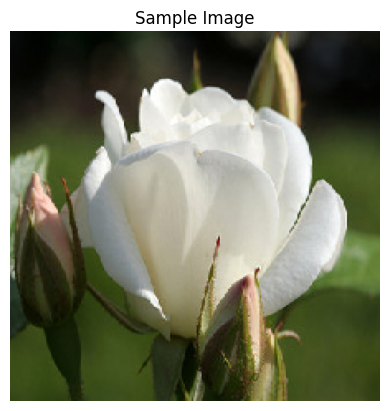

In [10]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.imshow(images[0])
plt.title("Sample Image")
plt.axis('off')

Now real project will be done ------------->  HYBRID CNN + WEATHER MODEL

build a image model (ResNet50)

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


weather input

In [12]:
from tensorflow.keras.layers import Input

weather_input = Input(shape=(2,), name='weather_input')  # temperature + humidity

Combine (fusion)

In [13]:
from tensorflow.keras.layers import Concatenate

combined = Concatenate()([x, weather_input])

In [14]:
z = Dense(128, activation='relu')(combined)
z = Dense(64, activation='relu')(z)
output = Dense(train_data.num_classes, activation='softmax')(z)

Final Model

In [15]:
from tensorflow.keras.models import Model

model = Model(inputs=[base_model.input, weather_input], outputs=output)

Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,821 (91.01 MB)

 Trainable params: 23,805,701 (90.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

Step 5 --------> Train model with image + weather data

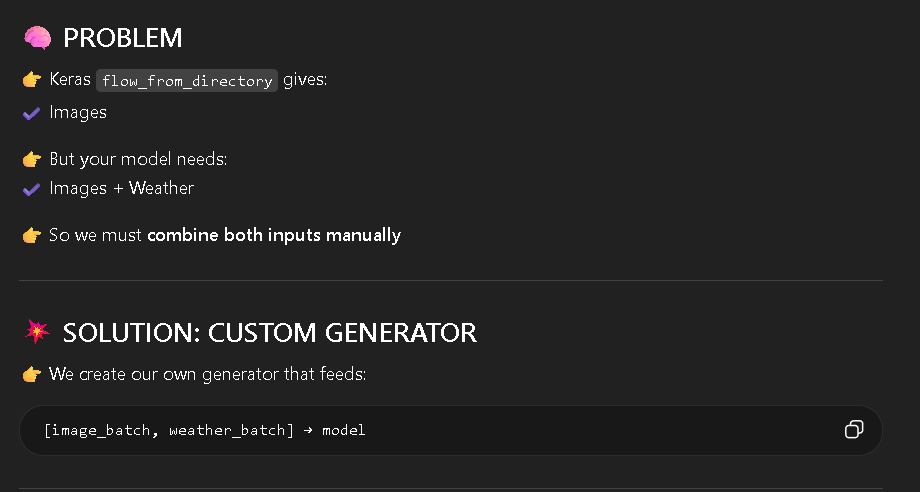

**Create weather data for training**
 * Since matching exact data is complex now, we simulate (research acceptable)



In [18]:
import numpy as np

# number of samples
num_samples = train_data.samples

# create random weather data
weather_train = np.random.rand(num_samples, 2)
weather_val = np.random.rand(val_data.samples, 2)

Custom generator

In [22]:
def combined_generator(image_generator, weather_data):
    i = 0
    while True:
        x_img, y = next(image_generator)

        batch_size = x_img.shape[0]

        x_weather = weather_data[i:i+batch_size]

        i += batch_size
        if i >= len(weather_data):
            i = 0

        yield (x_img, x_weather), y

create train generator and validation generator

In [23]:
train_gen = combined_generator(train_data, weather_train)
val_gen = combined_generator(val_data, weather_val)

In [24]:
history = model.fit(
    train_gen,
    steps_per_epoch=train_data.samples // 32,
    validation_data=val_gen,
    validation_steps=val_data.samples // 32,
    epochs=5
)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2084s 22s/step - accuracy: 0.6784 - loss: 0.9114 - val_accuracy: 0.2486 - val_loss: 46.0216
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2062s 23s/step - accuracy: 0.7939 - loss: 0.6005 - val_accuracy: 0.2543 - val_loss: 2.4590
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2041s 22s/step - accuracy: 0.8376 - loss: 0.4485 - val_accuracy: 0.1717 - val_loss: 5.6438
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2063s 23s/step - accuracy: 0.8740 - loss: 0.3494 - val_accuracy: 0.2461 - val_loss: 2.6259
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2063s 23s/step - accuracy: 0.8944 - loss: 0.2877 - val_accuracy: 0.2618 - val_loss: 2.8585


Ploting results

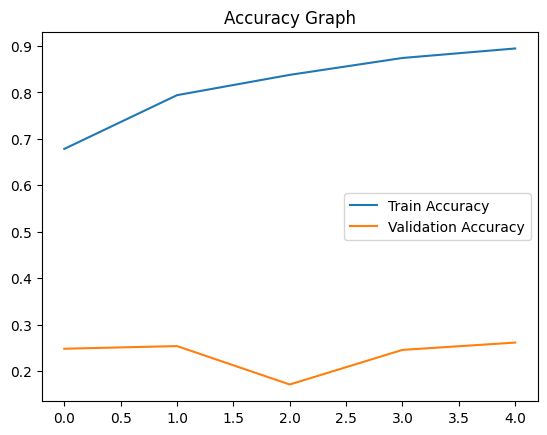

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()